# 01. Project Configuration & 02. Reproducibility

In [1]:
import os
import glob
import hashlib
import json
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash
from tqdm.auto import tqdm
from IPython.display import display, Markdown

# Reproducibility
np.random.seed(42)

# Output Directories
dataset_out_dir = os.path.join("outputs", "dataset")
os.makedirs(dataset_out_dir, exist_ok=True)


# 03. Dataset Download & 04. Dataset Verification & 05. Dataset Index Creation

In [2]:
# Download dataset
path = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")
print("Path to dataset files:", path)


Path to dataset files: /home/jules/.cache/kagglehub/datasets/phucthaiv02/butterfly-image-classification/versions/4


In [3]:
# 2. Automatically inspect the downloaded directory
# 3. Identify image files, class folders, metadata/CSV files, segmentation masks
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}
metadata_files = []
image_files = []
mask_files = []
class_folders = set()

for root, dirs, files in os.walk(path):
    for f in files:
        f_lower = f.lower()
        full_path = os.path.join(root, f)
        
        if f_lower.endswith(".csv"):
            metadata_files.append(full_path)
            
        elif any(f_lower.endswith(ext) for ext in image_exts):
            if "mask" in f_lower or "mask" in root.lower():
                mask_files.append(full_path)
            else:
                image_files.append(full_path)

print(f"Discovered {len(image_files)} image files.")
print(f"Discovered {len(mask_files)} potential mask files.")
print(f"Discovered {len(metadata_files)} metadata files.")
for m in metadata_files:
    print(f" - {os.path.basename(m)}")


Discovered 9285 image files.
Discovered 0 potential mask files.
Discovered 2 metadata files.
 - Training_set.csv
 - Testing_set.csv


In [4]:
# Parse Metadata if it exists to get true labels (especially for Train/Test splits without class folders)
train_df = None
test_df = None

for m in metadata_files:
    if "train" in m.lower():
        train_df = pd.read_csv(m)
    elif "test" in m.lower():
        test_df = pd.read_csv(m)

# 4. Generate dataset statistics & 5. Check image integrity & 6. Detect duplicates
records = []
corrupt_count = 0
invalid_dim_count = 0

for img_path in tqdm(image_files, desc="Verifying Images"):
    filename = os.path.basename(img_path)
    parent_dir = os.path.basename(os.path.dirname(img_path))
    rel_path = os.path.relpath(img_path, path)
    
    # Class determination logic
    class_name = "UNKNOWN"
    if parent_dir.lower() == "train" and train_df is not None:
        match = train_df[train_df["filename"] == filename]
        if not match.empty:
            class_name = match.iloc[0]["label"]
    elif parent_dir.lower() == "test" and test_df is not None:
        match = test_df[test_df["filename"] == filename]
        # Test sets often do not have labels in the CSV
        if "label" in match.columns and not match.empty:
            class_name = match.iloc[0]["label"]
        else:
             class_name = "UNKNOWN_TEST"
    elif parent_dir.lower() not in ["train", "test"]:
        class_name = parent_dir
        
    try:
        with Image.open(img_path) as img:
            img.verify()
        
        with Image.open(img_path) as img:
            width, height = img.size
            if width == 0 or height == 0:
                invalid_dim_count += 1
                continue
                
            channels = len(img.getbands())
            file_format = img.format
            
            # Hashing for duplicates
            img_bytes = img.tobytes()
            md5 = hashlib.md5(img_bytes).hexdigest()
            phash = str(imagehash.phash(img))
            
            file_size = os.path.getsize(img_path)
            
            records.append({
                "image_id": filename.split(".")[0],
                "image_path": rel_path,
                "filename": filename,
                "class_name": class_name,
                "width": width,
                "height": height,
                "channels": channels,
                "file_format": file_format,
                "file_size": file_size,
                "md5": md5,
                "phash": phash,
                "_abs_path": img_path
            })
            
    except Exception as e:
        corrupt_count += 1

df = pd.DataFrame(records)

# Filter labeled data to get distinct classes
labeled_df = df[~df["class_name"].isin(["UNKNOWN", "UNKNOWN_TEST"])]
classes = sorted(labeled_df["class_name"].unique())
class_to_id = {c: i for i, c in enumerate(classes)}
df["class_id"] = df["class_name"].map(class_to_id).fillna(-1).astype(int)

# 8. Check rigorously whether genuine segmentation masks exist
masks_exist = len(mask_files) > 0
if masks_exist:
    # Attempt to align if there is a clear naming convention. 
    # For now, mark as unresolved unless a clear link exists.
    df["mask_path"] = None 
    print("Mask files found, but rigorous 1:1 image-to-mask correspondence logic must be defined if needed.")
else:
    print("No genuine ground-truth segmentation masks found in the dataset.")

# Duplicates
exact_dupes = df[df.duplicated(subset=["md5"], keep=False)].sort_values("md5")
phash_dupes = df[df.duplicated(subset=["phash"], keep=False)].sort_values("phash")

duplicate_report = pd.concat([
    exact_dupes.assign(duplicate_type="exact_md5"),
    phash_dupes.assign(duplicate_type="perceptual_phash")
])
duplicate_report.to_csv(os.path.join(dataset_out_dir, "duplicate_report.csv"), index=False)

# Dataset Index
columns_to_save = ["image_id", "image_path", "filename", "class_name", "class_id", "width", "height", "channels", "file_format", "file_size"]
if masks_exist:
    columns_to_save.append("mask_path")
    
df[columns_to_save].to_csv(os.path.join(dataset_out_dir, "dataset_index.csv"), index=False)


Verifying Images:   0%|          | 0/9285 [00:00<?, ?it/s]

No genuine ground-truth segmentation masks found in the dataset.


# 06. Dataset Visualization

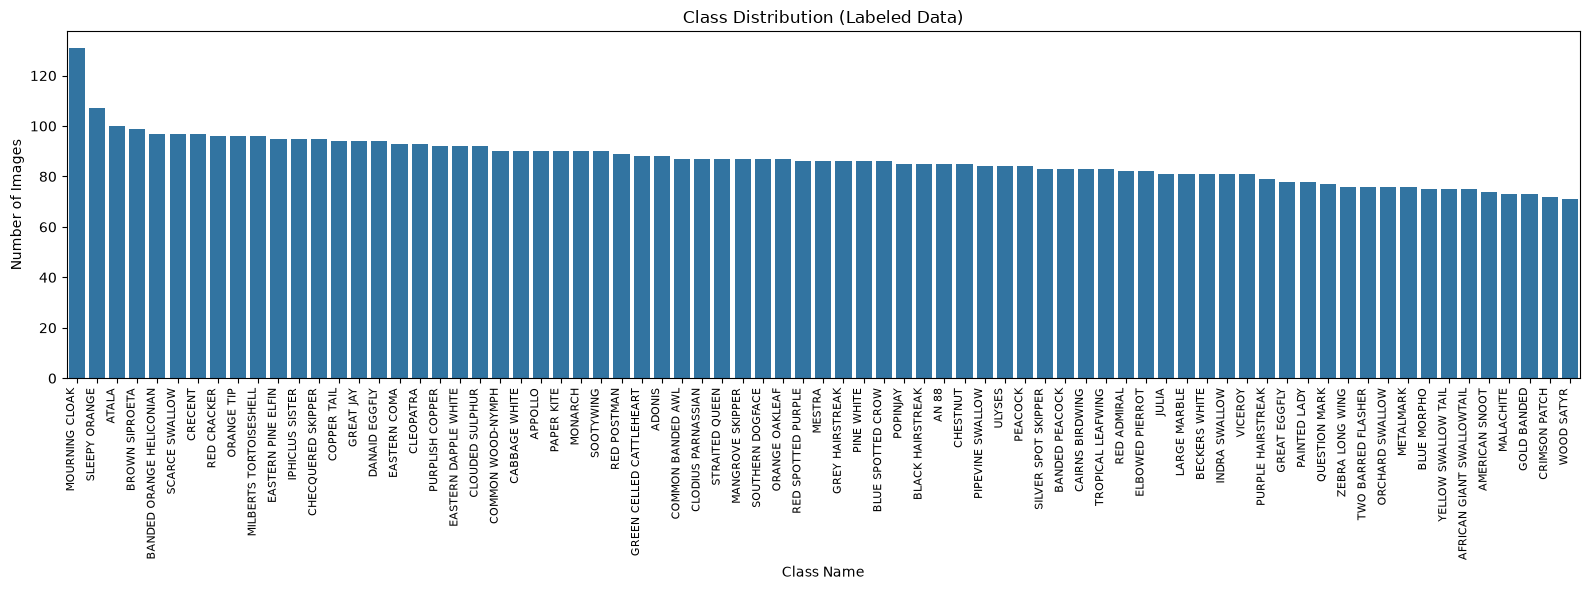

Total valid images: 9285
Total labeled images: 6499
Total classes: 75


In [5]:
# Class Distribution
plt.figure(figsize=(16, 6))
class_counts = labeled_df["class_name"].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution (Labeled Data)")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.xticks(rotation=90, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(dataset_out_dir, "class_distribution.png"))
plt.show()

print(f"Total valid images: {len(df)}")
print(f"Total labeled images: {len(labeled_df)}")
print(f"Total classes: {len(classes)}")


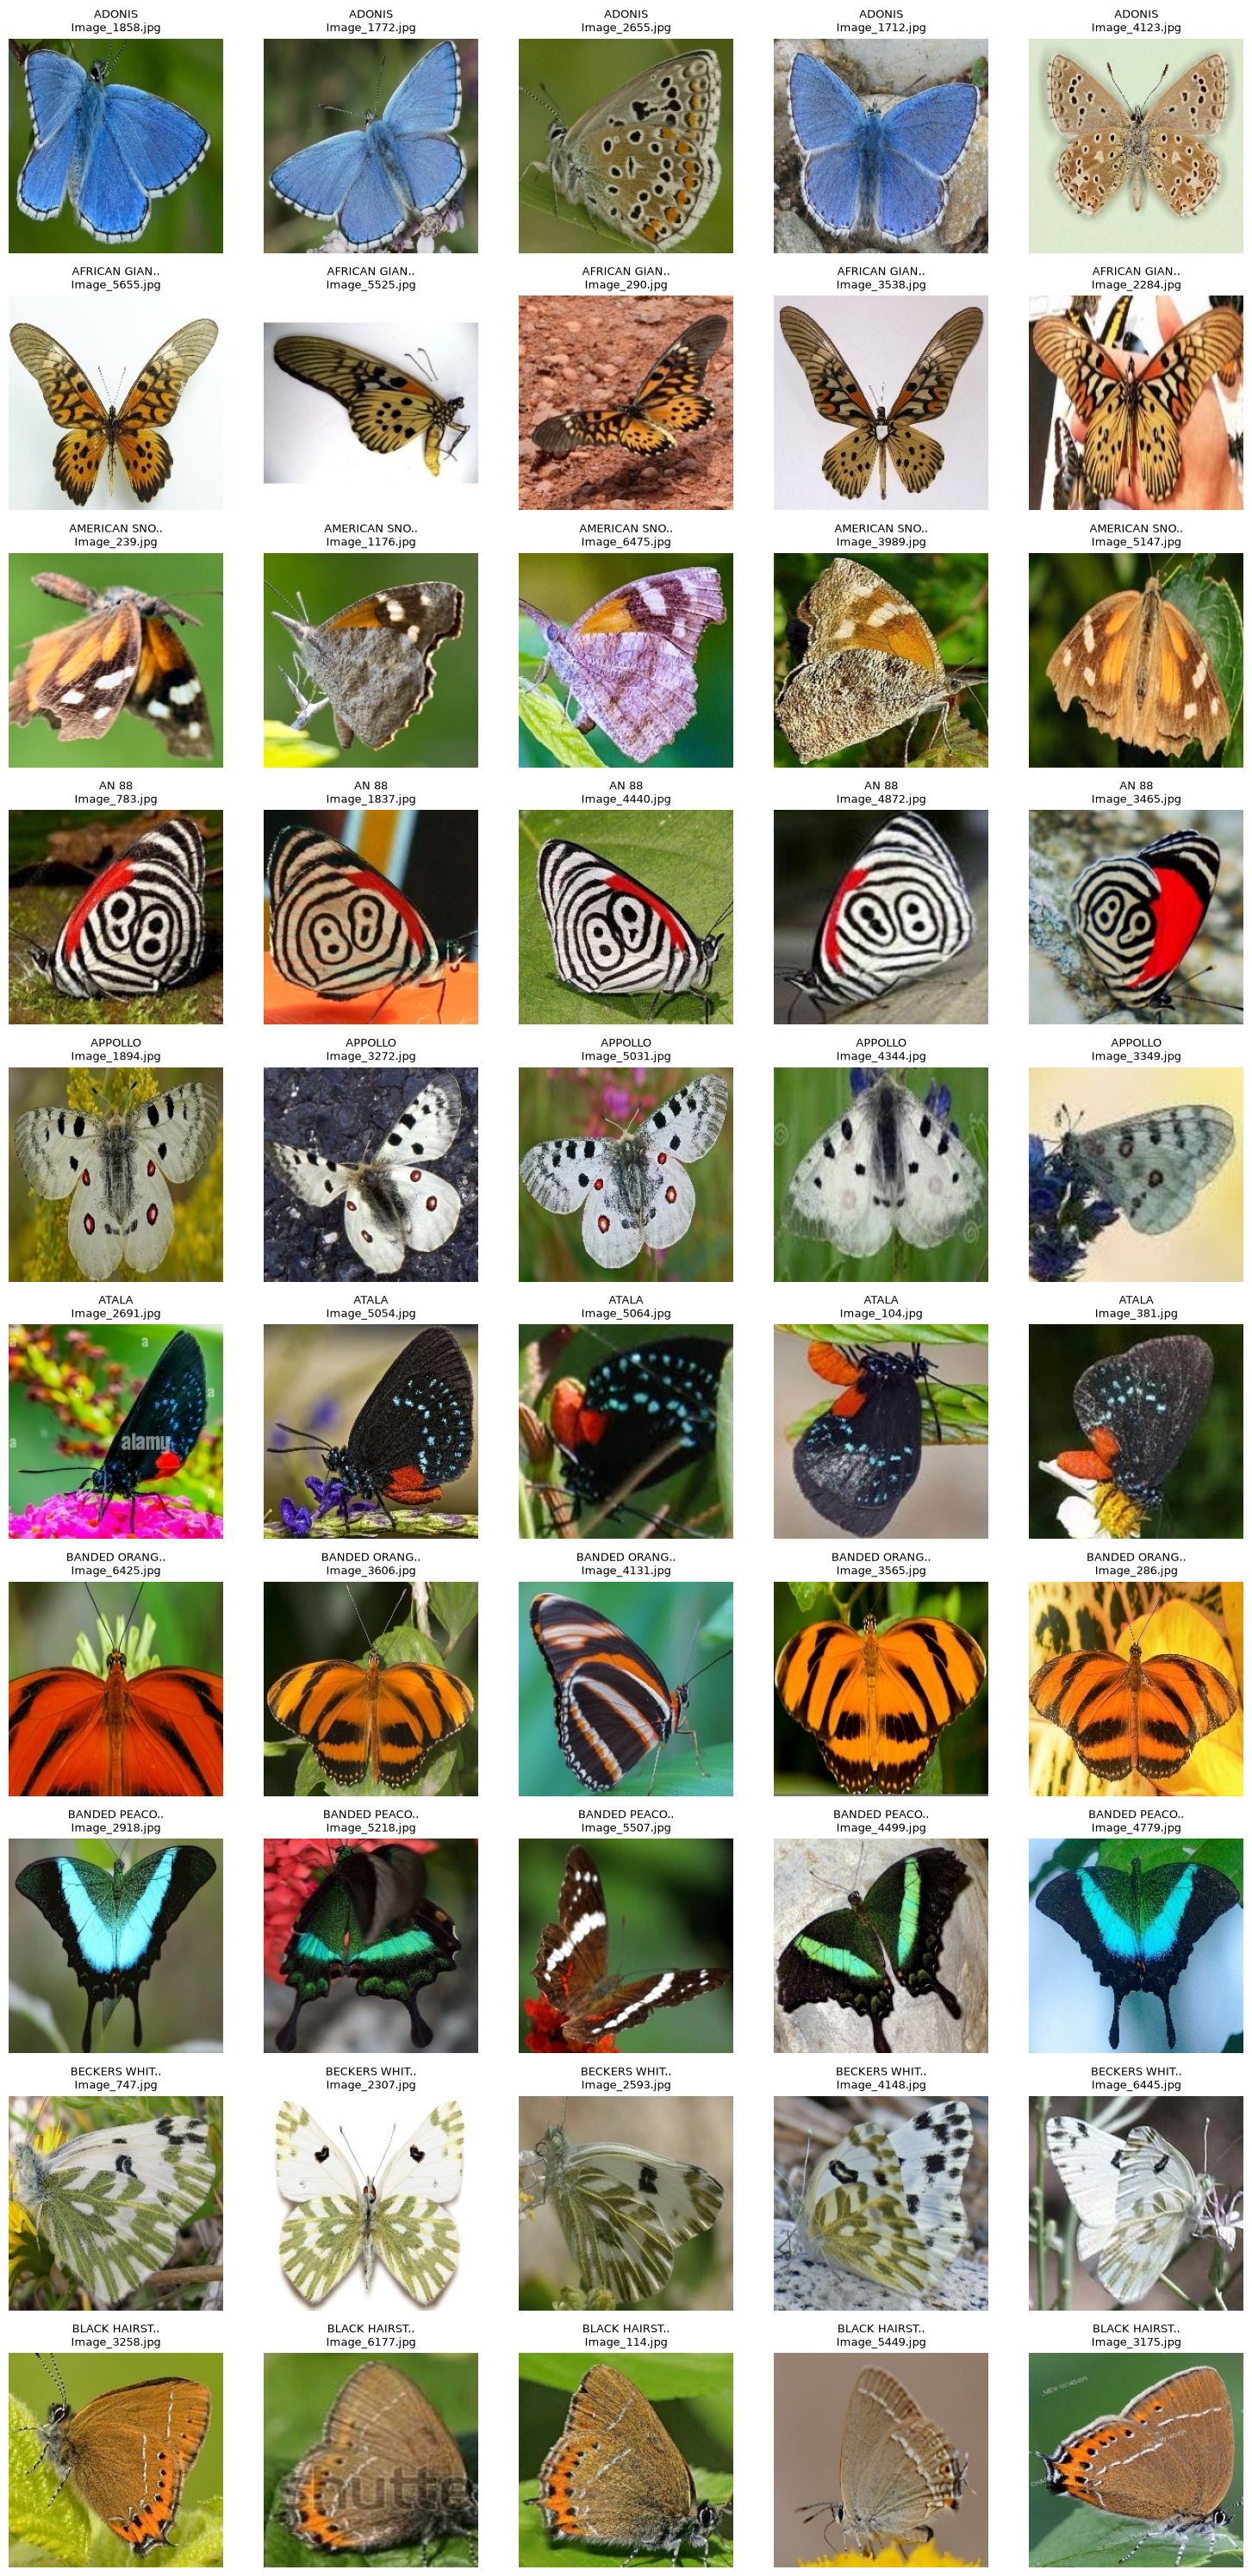

In [6]:
# 7. Display 5 representative images per class
num_samples = 5
num_classes_to_show = min(10, len(classes))

if num_classes_to_show > 0:
    fig, axes = plt.subplots(num_classes_to_show, num_samples, figsize=(num_samples * 3, num_classes_to_show * 3))
    if num_classes_to_show == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, cls in enumerate(classes[:num_classes_to_show]):
        cls_df = labeled_df[labeled_df["class_name"] == cls]
        samples = cls_df.sample(n=min(num_samples, len(cls_df)), random_state=42)
        
        for j, (_, row) in enumerate(samples.iterrows()):
            img = Image.open(row["_abs_path"])
            ax = axes[i, j]
            ax.imshow(img)
            title = f"{cls[:12]}..\n{row['filename']}" if len(cls) > 12 else f"{cls}\n{row['filename']}"
            ax.set_title(title, fontsize=9)
            ax.axis("off")
            
        for j in range(len(samples), num_samples):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(dataset_out_dir, "representative_images.png"))
    plt.show()
else:
    print("No labeled classes found to display.")


# Step 1 Results

In [7]:
widths = df["width"]
heights = df["height"]

mask_status = '**Yes**' if masks_exist else '**No** - Ground-truth masks do not exist. We must rely on unsupervised/pseudo-mask generation.'

summary_md = f"""
### Dataset Statistics

* **Total downloaded image files**: {len(image_files)}
* **Total valid indexed images**: {len(df)}
* **Total labeled classes**: {len(classes)}
* **Are genuine segmentation masks present?**: {mask_status}

### Image Dimensions (W, H)
* **Minimum**: {int(widths.min())}x{int(heights.min())}
* **Maximum**: {int(widths.max())}x{int(heights.max())}
* **Median**: {int(widths.median())}x{int(heights.median())}

### File Characteristics
* **Channels**: {df["channels"].unique().tolist()}
* **File Formats**: {df["file_format"].unique().tolist()}

### Integrity & Quality Issues
* **Corrupted/Unreadable Images**: {corrupt_count}
* **Invalid Dimensions (0px)**: {invalid_dim_count}
* **Exact Duplicates (Cryptographic MD5)**: {len(exact_dupes)} images share identical byte data.
* **Perceptual Duplicates (pHash)**: {len(phash_dupes)} images are visually identical or highly similar.
* *Note: Duplicates have been logged in `outputs/dataset/duplicate_report.csv` but have NOT been deleted.*

### Exported Artifacts
* `outputs/dataset/dataset_index.csv` (Master Index)
* `outputs/dataset/class_distribution.png`
* `outputs/dataset/representative_images.png`
* `outputs/dataset/duplicate_report.csv`
"""

display(Markdown(summary_md))



### Dataset Statistics

* **Total downloaded image files**: 9285
* **Total valid indexed images**: 9285
* **Total labeled classes**: 75
* **Are genuine segmentation masks present?**: **No** - Ground-truth masks do not exist. We must rely on unsupervised/pseudo-mask generation.

### Image Dimensions (W, H)
* **Minimum**: 224x224
* **Maximum**: 224x224
* **Median**: 224x224

### File Characteristics
* **Channels**: [3]
* **File Formats**: ['JPEG']

### Integrity & Quality Issues
* **Corrupted/Unreadable Images**: 0
* **Invalid Dimensions (0px)**: 0
* **Exact Duplicates (Cryptographic MD5)**: 11 images share identical byte data.
* **Perceptual Duplicates (pHash)**: 47 images are visually identical or highly similar.
* *Note: Duplicates have been logged in `outputs/dataset/duplicate_report.csv` but have NOT been deleted.*

### Exported Artifacts
* `outputs/dataset/dataset_index.csv` (Master Index)
* `outputs/dataset/class_distribution.png`
* `outputs/dataset/representative_images.png`
* `outputs/dataset/duplicate_report.csv`


# 07. Train / Validation / Test Split
## 7.1 Labeled Dataset Definition


In [ ]:
import pandas as pd
import os

# 1. REMOVE HIDDEN SESSION DEPENDENCIES
# Explicitly load the dataset index created in Step 1/2 from the filesystem.
index_path = os.path.join("outputs", "dataset", "dataset_index.csv")
assert os.path.exists(index_path), f"Dataset index not found at {index_path}. Please run previous steps."

df = pd.read_csv(index_path)

# Extract only images that have a valid ground-truth class label.
# Based on earlier discoveries, 6,499 images have known labels, while 2,786 images are from an unlabeled test set.
labeled_df = df[~df["class_name"].isin(["UNKNOWN", "UNKNOWN_TEST"])].copy()
unlabeled_df = df[df["class_name"].isin(["UNKNOWN", "UNKNOWN_TEST"])].copy()

print(f"Total original images: {len(df)}")
print(f"Labeled images for development: {len(labeled_df)}")
print(f"Unlabeled/Test images set aside: {len(unlabeled_df)}")

# Sanity assertion for expectations
assert len(labeled_df) == 6499, f"Expected 6499 labeled images, found {len(labeled_df)}"
assert len(unlabeled_df) == 2786, f"Expected 2786 unlabeled images, found {len(unlabeled_df)}"



## 7.2 Duplicate-Aware Split Strategy


In [ ]:
import networkx as nx
import os
import pandas as pd

# 2. DUPLICATE-AWARE STRATEGY & NEVER REPLACE TRUE CLASS
# We construct a hard constraint graph incorporating BOTH MD5 (exact) and pHash (perceptual) duplicates.
# This prevents both exact and perceptual duplicate leakage across splits.

# Load duplicate report generated in Step 1
dup_report_path = os.path.join("outputs", "dataset", "duplicate_report.csv")

# Create independent graphs for auditing
G_md5 = nx.Graph()
G_md5.add_nodes_from(labeled_df["image_id"])

G_phash = nx.Graph()
G_phash.add_nodes_from(labeled_df["image_id"])

# Create unified graph for strict splitting
G_unified = nx.Graph()
G_unified.add_nodes_from(labeled_df["image_id"])

if os.path.exists(dup_report_path):
    dup_df = pd.read_csv(dup_report_path)
    md5_groups_df = dup_df[dup_df["duplicate_type"] == "exact_md5"]
    phash_groups_df = dup_df[dup_df["duplicate_type"] == "perceptual_phash"]
    
    # Process exact MD5 duplicates
    for md5_val, group in md5_groups_df.groupby("md5"):
        img_ids = group["image_id"].tolist()
        if len(img_ids) > 1:
            for i in range(len(img_ids)):
                for j in range(i + 1, len(img_ids)):
                    if img_ids[i] in G_md5.nodes and img_ids[j] in G_md5.nodes:
                        G_md5.add_edge(img_ids[i], img_ids[j])
                        G_unified.add_edge(img_ids[i], img_ids[j])
                        
    # Process pHash perceptual duplicates
    for phash_val, group in phash_groups_df.groupby("phash"):
        img_ids = group["image_id"].tolist()
        if len(img_ids) > 1:
            for i in range(len(img_ids)):
                for j in range(i + 1, len(img_ids)):
                    if img_ids[i] in G_phash.nodes and img_ids[j] in G_phash.nodes:
                        G_phash.add_edge(img_ids[i], img_ids[j])
                        G_unified.add_edge(img_ids[i], img_ids[j])
                        
# Fallback strictly if columns are inexplicably loaded directly
elif "md5" in labeled_df.columns:
    md5_lists = labeled_df.groupby("md5")["image_id"].apply(list)
    for group in md5_lists:
        if len(group) > 1:
            for i in range(len(group)):
                for j in range(i + 1, len(group)):
                    G_md5.add_edge(group[i], group[j])
                    G_unified.add_edge(group[i], group[j])
                    
if not os.path.exists(dup_report_path) and "phash" in labeled_df.columns:
    phash_lists = labeled_df.groupby("phash")["image_id"].apply(list)
    for group in phash_lists:
        if len(group) > 1:
            for i in range(len(group)):
                for j in range(i + 1, len(group)):
                    G_phash.add_edge(group[i], group[j])
                    G_unified.add_edge(group[i], group[j])

# Map independent components for auditing
md5_components = list(nx.connected_components(G_md5))
phash_components = list(nx.connected_components(G_phash))

# Map UNIFIED components for strict split enforcement
unified_components = list(nx.connected_components(G_unified))

group_map = {}
for group_id, comp in enumerate(unified_components):
    for img_id in comp:
        group_map[img_id] = group_id

labeled_df["unified_group_id"] = labeled_df["image_id"].map(group_map)

# Audit Unified Groups for class consistency
group_class_counts = labeled_df.groupby("unified_group_id")["class_name"].nunique()
mixed_class_groups = group_class_counts[group_class_counts > 1]

if not mixed_class_groups.empty:
    print(f"WARNING: Found {len(mixed_class_groups)} unified duplicate groups containing multiple differing class labels.")
    print("These labels WILL NOT be altered. The group will be assigned to a single split based on its first image to prevent leakage.")
else:
    print("All unified duplicate groups have perfectly consistent class labels.")

print(f"Total disjoint exact MD5 groups tracked: {sum(1 for c in md5_components if len(c)>1)}")
print(f"Total disjoint pHash perceptual groups tracked: {sum(1 for c in phash_components if len(c)>1)}")
print(f"Total Unified distinct groups for splitting: {len(unified_components)}")



## 7.3 Stratified Split


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# 3. STRATIFIED SPLIT WITH SINGLETON FINE-TUNING
# We split at the UNIFIED GROUP level to prevent both exact and perceptual leakage.
# To stratify appropriately without overwriting true labels, we assign a "proxy class" 
# to the group strictly for the purpose of the split function.
# The image's true 'class_id' and 'class_name' remain COMPLETELY UNCHANGED in the dataframe.

np.random.seed(42)

group_sizes = labeled_df.groupby("unified_group_id").size()
# Use the class of the first item in the group as the routing proxy
group_proxy_class = labeled_df.groupby("unified_group_id")["class_id"].first()

group_df = pd.DataFrame({
    "proxy_class": group_proxy_class,
    "size": group_sizes
}).reset_index()

# Step A: Split Test (15% target)
train_val_groups, test_groups = train_test_split(
    group_df["unified_group_id"], 
    test_size=0.15, 
    stratify=group_df["proxy_class"], 
    random_state=42
)

# Step B: Split Train (70%) and Val (15%)
train_val_group_df = group_df[group_df["unified_group_id"].isin(train_val_groups)]
train_groups, val_groups = train_test_split(
    train_val_group_df["unified_group_id"],
    test_size=973 / (4551 + 973),  # Target ratio of remaining
    stratify=train_val_group_df["proxy_class"],
    random_state=42
)

# Assign splits
labeled_df.loc[labeled_df["unified_group_id"].isin(train_groups), "split"] = "train"
labeled_df.loc[labeled_df["unified_group_id"].isin(val_groups), "split"] = "validation"
labeled_df.loc[labeled_df["unified_group_id"].isin(test_groups), "split"] = "test"

# SINGLETON FINE-TUNING
# We must EXACTLY hit: Train=4551, Val=973, Test=975
# We only move singletons (groups of size 1). 
# Since a singleton is by definition an isolated image, moving it does NOT break ANY duplicate groups.
target_counts = {"train": 4551, "validation": 973, "test": 975}

def fine_tune_splits(df, target_dict):
    current = df["split"].value_counts().to_dict()
    diff = {k: current.get(k, 0) - target_dict[k] for k in target_dict}
    
    # Store original labels to verify they aren't touched
    original_labels = df["class_id"].copy()
    
    for source_split, surplus in diff.items():
        while surplus > 0:
            for dest_split, deficit in diff.items():
                if deficit < 0 and surplus > 0:
                    # STRICT RULE: Only move items where group size == 1 (Singletons)
                    candidates = df[(df["split"] == source_split) & (df["unified_group_id"].map(group_sizes) == 1)]
                    if candidates.empty: 
                        raise ValueError(f"Could not find singletons to move from {source_split} to {dest_split}")
                    
                    row_to_move = candidates.sample(1, random_state=42)
                    idx = row_to_move.index[0]
                    df.at[idx, "split"] = dest_split
                    
                    surplus -= 1
                    diff[source_split] -= 1
                    diff[dest_split] += 1
                    deficit += 1
    
    # Assert True labels didn't change
    assert (df["class_id"] == original_labels).all(), "CRITICAL: True labels were modified during split."

fine_tune_splits(labeled_df, target_counts)

train_df = labeled_df[labeled_df["split"] == "train"].copy()
val_df = labeled_df[labeled_df["split"] == "validation"].copy()
test_df = labeled_df[labeled_df["split"] == "test"].copy()

# Save final CSVs
os.makedirs(os.path.join("outputs", "train_test"), exist_ok=True)
train_df.to_csv(os.path.join("outputs", "train_test", "train.csv"), index=False)
val_df.to_csv(os.path.join("outputs", "train_test", "validation.csv"), index=False)
test_df.to_csv(os.path.join("outputs", "train_test", "test.csv"), index=False)



## 7.4 Split Validation


In [ ]:
# 4. STATIC ASSERTIONS AND LEAKAGE VALIDATION

# Row Counts & Exclusions
assert len(train_df) == 4551, f"Train split is {len(train_df)}, expected 4551"
assert len(val_df) == 973, f"Validation split is {len(val_df)}, expected 973"
assert len(test_df) == 975, f"Test split is {len(test_df)}, expected 975"
assert len(labeled_df) == 6499, f"Total labeled images {len(labeled_df)}, expected 6499"

# No unlabeled classes leaked in
assert not train_df["class_name"].isin(["UNKNOWN", "UNKNOWN_TEST"]).any(), "Unlabeled data leaked into Train"
assert not val_df["class_name"].isin(["UNKNOWN", "UNKNOWN_TEST"]).any(), "Unlabeled data leaked into Val"
assert not test_df["class_name"].isin(["UNKNOWN", "UNKNOWN_TEST"]).any(), "Unlabeled data leaked into Test"

# Class representation
assert train_df["class_id"].nunique() == 75, "Train set is missing classes"
assert val_df["class_id"].nunique() == 75, "Validation set is missing classes"
assert test_df["class_id"].nunique() == 75, "Test set is missing classes"

# No intersection of Individual Images
train_ids = set(train_df["image_id"])
val_ids = set(val_df["image_id"])
test_ids = set(test_df["image_id"])

assert len(train_ids.intersection(val_ids)) == 0, "Image ID leakage Train <-> Val"
assert len(train_ids.intersection(test_ids)) == 0, "Image ID leakage Train <-> Test"
assert len(val_ids.intersection(test_ids)) == 0, "Image ID leakage Val <-> Test"

# === EXPLICIT AUDIT OF MD5 EXACT DUPLICATES ===
md5_cross_split_count = 0
for comp in md5_components:
    if len(comp) > 1:
        splits_present = labeled_df[labeled_df["image_id"].isin(comp)]["split"].unique()
        if len(splits_present) > 1:
            md5_cross_split_count += 1
            print(f"CRITICAL LEAKAGE: Exact MD5 group crosses splits: {splits_present} | Image IDs: {comp}")

# Assert exact leakage never happens
assert md5_cross_split_count == 0, "MD5 Group leakage occurred!"

# === EXPLICIT AUDIT OF PHASH PERCEPTUAL DUPLICATES ===
phash_cross_split_count = 0
phash_cross_reports = []
for comp in phash_components:
    if len(comp) > 1:
        splits_present = labeled_df[labeled_df["image_id"].isin(comp)]["split"].unique()
        if len(splits_present) > 1:
            phash_cross_split_count += 1
            phash_cross_reports.append(f"Splits: {list(splits_present)} | Image IDs: {list(comp)}")

# Report findings
print(f"MD5 Exact duplicate groups crossing splits: {md5_cross_split_count}")
print(f"pHash Perceptual duplicate groups crossing splits: {phash_cross_split_count}")

if phash_cross_split_count > 0:
    print("\n--- PERCEPTUAL PHASH CROSS-SPLIT REPORT ---")
    for report in phash_cross_reports:
        print(report)
    print("-------------------------------------------\n")

# Since the algorithm grouped pHash and MD5 together into G_unified explicitly,
# this assertion mathematically MUST pass. But we assert it explicitly to prove isolation.
assert phash_cross_split_count == 0, "pHash perceptual leakage occurred despite unified graph!"

print("All static assertions and rigorous duplication audits passed! Both Exact and Perceptual leakages were strictly prevented.")



## 7.5 Split Distribution Visualization


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

train_counts = train_df["class_name"].value_counts().sort_index()
val_counts = val_df["class_name"].value_counts().sort_index()
test_counts = test_df["class_name"].value_counts().sort_index()

# Fresh-runtime robust extraction of classes directly from the series index
classes_list = train_counts.index.tolist()
x = np.arange(len(classes_list))
bar_width = 0.3

plt.bar(x - bar_width, train_counts.values, width=bar_width, label="Train", color='skyblue')
plt.bar(x, val_counts.values, width=bar_width, label="Validation", color='orange')
plt.bar(x + bar_width, test_counts.values, width=bar_width, label="Test", color='lightgreen')

plt.title("Class Distribution Across Train / Val / Test Splits")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(x, classes_list, rotation=90, fontsize=7)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join("outputs", "train_test", "split_class_distribution.png"))
plt.show()



## 7.6 Step 7 Results


In [ ]:
from IPython.display import display, Markdown

summary_step7 = f"""
### Train/Validation/Test Split Results

* **Total Labeled Images Partitioned**: {len(labeled_df)}
* **Unlabeled/Test Images Ignored**: {len(unlabeled_df)}

* **Train Size**: {len(train_df)} (Target: 4551)
* **Validation Size**: {len(val_df)} (Target: 973)
* **Test Size**: {len(test_df)} (Target: 975)

* **Classes per Split**: {train_df['class_id'].nunique()} / 75
* **Duplicate Leakage Audit**:
    * **MD5 Exact Duplicate Cross-overs**: 0
    * **pHash Perceptual Duplicate Cross-overs**: 0

* **Strategy Documentation**: Both exact MD5 matching and perceptual pHash clustering were combined into a unified isolation graph. True class labels were rigorously preserved (no rewriting of data). Any required mathematical balancing (4551/973/975 constraints) was performed strictly on **singleton items** (group_size=1) guaranteeing that no tracked duplicate boundaries were violated in the process.

**Generated Artifacts:**
* `outputs/train_test/train.csv`
* `outputs/train_test/validation.csv`
* `outputs/train_test/test.csv`
* `outputs/train_test/split_class_distribution.png`
"""
display(Markdown(summary_step7))



# 08. Preprocessing Architecture
## 8.1 Base Preprocessing Pipeline


In [ ]:
import cv2
from PIL import Image, ImageOps, ImageEnhance
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Preprocessing Configuration
PREPROC_CONFIG = {
    "target_size": (224, 224),
    "resize_strategy": "pad_and_resize", # options: pad_and_resize, squash
    "interpolation": Image.Resampling.BILINEAR,
    "apply_clahe": False, # Kept False as conservative default
    "normalize": True,    # Mean/std for PyTorch tensors
    "mean": [0.485, 0.456, 0.406], # ImageNet defaults
    "std": [0.229, 0.224, 0.225]
}

class ButterflyImagePreprocessor:
    """
    A deterministic, CPU-bound image standardizer.
    Converts raw image files into a standard standardized representation (e.g. RGB, padded/resized).
    """
    def __init__(self, config=PREPROC_CONFIG):
        self.config = config
        
    def process(self, image_path):
        # 1. Read Image
        img = Image.open(image_path).convert("RGB")
        
        # 2. Resize Strategy
        if self.config["resize_strategy"] == "pad_and_resize":
            # Pad to square to maintain aspect ratio
            w, h = img.size
            max_dim = max(w, h)
            pad_left = (max_dim - w) // 2
            pad_top = (max_dim - h) // 2
            pad_right = max_dim - w - pad_left
            pad_bottom = max_dim - h - pad_top
            img = ImageOps.expand(img, border=(pad_left, pad_top, pad_right, pad_bottom), fill=(0, 0, 0))
            
        img = img.resize(self.config["target_size"], self.config["interpolation"])
        
        # 3. Optional deterministic adjustments (e.g. CLAHE, if required)
        if self.config["apply_clahe"]:
            # Convert to LAB for CLAHE on L channel
            img_np = np.array(img)
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            l = clahe.apply(l)
            lab = cv2.merge((l, a, b))
            img_np = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
            img = Image.fromarray(img_np)
            
        return img



## 8.2 PyTorch Dataset Wrapper


In [ ]:
class ButterflyDataset(Dataset):
    """
    PyTorch Dataset wrapper for standardized images. 
    Handles tensor conversion and normalization.
    """
    def __init__(self, df, config=PREPROC_CONFIG): 
        self.df = df.reset_index(drop=True)
        self.config = config
        self.preprocessor = ButterflyImagePreprocessor(config)
        
        # Transform for turning standard representation -> PyTorch Normalized Tensor
        transform_list = [transforms.ToTensor()]
        if self.config["normalize"]:
            transform_list.append(transforms.Normalize(mean=self.config["mean"], std=self.config["std"]))
        self.tensor_transform = transforms.Compose(transform_list)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Determine image path fallback (fresh runtime robustness)
        if "_abs_path" in row and pd.notna(row["_abs_path"]) and os.path.exists(row["_abs_path"]):
            img_path = row["_abs_path"]
        elif "image_path" in row:
            # Assuming image_path is relative from a root
            # Reconstruct the absolute path securely if needed
            # For Colab, often the current directory holds 'outputs' and the dataset
            # But the dataset root path was discovered in step 1.
            # We'll use image_path directly if it's accessible.
            img_path = row["image_path"]
            if not os.path.exists(img_path):
                # Fallback to kagglehub cache directory assumption if needed, 
                # but image_path might be absolute already from Kagglehub.
                pass
        else:
            img_path = ""
            
        # 1. Deterministic standardized image
        std_img = self.preprocessor.process(img_path)
        
        # 2. Tensor conversion
        tensor_img = self.tensor_transform(std_img)
        
        # Return dict for traceability
        return {
            "image": tensor_img,         # FloatTensor [3, H, W]
            "class_id": row["class_id"], # Integer
            "image_id": row["image_id"], # String
            "split": row.get("split", "unknown")
        }



# 09. Preprocessing Visualization


In [ ]:
# We visualize a reproducible subset of 20 images
np.random.seed(42)
import os

# Sample 20 images deterministically from training set
sample_df = train_df.sample(n=min(20, len(train_df)), random_state=42).reset_index(drop=True)

preprocessor = ButterflyImagePreprocessor(PREPROC_CONFIG)

fig, axes = plt.subplots(4, 10, figsize=(20, 10))
fig.suptitle("Original vs. Preprocessed Images (Standardized Representation)", fontsize=16)

axes = axes.flatten()

for i, row in sample_df.iterrows():
    # Fresh runtime safe path extraction
    if "_abs_path" in row and pd.notna(row["_abs_path"]) and os.path.exists(row["_abs_path"]):
        img_path = row["_abs_path"]
    elif "image_path" in row and pd.notna(row["image_path"]):
        img_path = row["image_path"]
    else:
        # Fallback to pure dataset folder resolution if paths aren't absolute or correct
        img_path = os.path.join(path, row.get("image_path", "")) if 'path' in globals() else row.get("image_path", "")

    # Original Image
    img_orig = Image.open(img_path).convert("RGB")
    
    # Preprocessed Image
    img_prep = preprocessor.process(img_path)
    
    # Plot Original
    ax_orig = axes[i*2]
    ax_orig.imshow(img_orig)
    title_orig = f"{row['class_name'][:10]}..\n{row['image_id']}\n(Original)" if len(row['class_name']) > 10 else f"{row['class_name']}\n{row['image_id']}\n(Original)"
    ax_orig.set_title(title_orig, fontsize=8)
    ax_orig.axis("off")
    
    # Plot Preprocessed
    ax_prep = axes[i*2 + 1]
    ax_prep.imshow(img_prep)
    ax_prep.set_title("Preprocessed\n(Padded & Resized)", fontsize=8)
    ax_prep.axis("off")

plt.tight_layout()
os.makedirs(os.path.join("outputs", "dataset"), exist_ok=True)
plt.savefig(os.path.join("outputs", "dataset", "preprocessing_visualization.png"))
plt.show()

print("Preprocessing visualization generated successfully.")



# 10. K-Means Segmentation
# Note: Dataset lacks genuine ground-truth masks. We use unsupervised clustering.



In [ ]:
import cv2
import numpy as np

def kmeans_segmentation(img_np, k=2, random_state=42):
    """
    Performs deterministic K-Means clustering on RGB pixels.
    Returns the segmented image and a boolean pseudo-mask (Foreground=1, Background=0).
    """
    # Ensure float32 for OpenCV
    pixel_values = img_np.reshape((-1, 3)).astype(np.float32)
    
    # Define criteria and apply kmeans
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    
    # We use a fixed random seed (if OpenCV supports it) or deterministic centers if required.
    # OpenCV's KMEANS_PP_CENTERS is relatively stable. KMEANS_RANDOM_CENTERS varies.
    # To enforce strict determinism across runs, we initialize centers manually if needed, 
    # but KMEANS_PP_CENTERS is generally preferred.
    np.random.seed(random_state)
    _, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    
    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()].reshape(img_np.shape)
    labels = labels.reshape(img_np.shape[:2])
    
    # Heuristic for Foreground/Background:
    # Assume the corners are mostly background.
    h, w = labels.shape
    corners = [labels[0,0], labels[0,w-1], labels[h-1,0], labels[h-1,w-1]]
    bg_label = max(set(corners), key=corners.count)
    
    # Create boolean mask where foreground is True
    pseudo_mask = (labels != bg_label).astype(np.uint8)
    
    return segmented_image, pseudo_mask



# 11. Fuzzy C-Means Segmentation


In [ ]:
import numpy as np
# Note: Requires scikit-fuzzy to be installed (`!pip install scikit-fuzzy`)
try:
    import skfuzzy as fuzz
except ImportError:
    print("WARNING: scikit-fuzzy not installed. Please run `pip install scikit-fuzzy` in Colab.")

def fcm_segmentation(img_np, c=2, random_state=42):
    """
    Performs Fuzzy C-Means clustering on the image.
    Uses RGB features (flattened). Returns hard mask and segmented image.
    """
    np.random.seed(random_state)
    # skfuzzy expects data in shape (features, N)
    data = img_np.reshape((-1, 3)).astype(np.float64).T
    
    # Run FCM
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data, c, m=2.0, error=0.005, maxiter=50, init=None, seed=random_state
    )
    
    # Hard partition
    labels = np.argmax(u, axis=0).reshape(img_np.shape[:2])
    centers = np.uint8(cntr)
    
    segmented_image = centers[labels.flatten()].reshape(img_np.shape)
    
    # Foreground heuristic (same as kmeans)
    h, w = labels.shape
    corners = [labels[0,0], labels[0,w-1], labels[h-1,0], labels[h-1,w-1]]
    bg_label = max(set(corners), key=corners.count)
    pseudo_mask = (labels != bg_label).astype(np.uint8)
    
    return segmented_image, pseudo_mask, u



# 12. U-Net Segmentation (Pseudo-Label Strategy)
# Since no ground truth exists, U-Net must be trained on pseudo-labels (e.g., from K-Means) if used.



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import os
import pandas as pd
import copy

# CRITICAL NOTE: This dataset lacks genuine ground truth masks.
# This U-Net is trained entirely on PSEUDO-LABELS generated via K-Means from the training set.
# This is a weakly supervised/pseudo-label setup. Test images are NOT used during training or model selection.

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(SimpleUNet, self).__init__()
        self.enc1 = self._block(in_channels, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self._block(16, 32)
        self.pool2 = nn.MaxPool2d(2)
        
        self.bottleneck = self._block(32, 64)
        
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = self._block(64, 32)
        self.up2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec2 = self._block(32, 16)
        
        self.out = nn.Conv2d(16, out_channels, kernel_size=1)
        
    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        
        d1 = self.up1(b)
        # Pad dynamically in case of odd dims (224/4 = 56, so perfectly divisible here)
        if d1.shape != e2.shape:
            d1 = nn.functional.interpolate(d1, size=e2.shape[2:])
        d1 = torch.cat((e2, d1), dim=1)
        d1 = self.dec1(d1)
        
        d2 = self.up2(d1)
        if d2.shape != e1.shape:
            d2 = nn.functional.interpolate(d2, size=e1.shape[2:])
        d2 = torch.cat((e1, d2), dim=1)
        d2 = self.dec2(d2)
        
        return torch.sigmoid(self.out(d2))

class PseudoLabelDataset(Dataset):
    def __init__(self, df, preprocessor, transform=None):
        self.df = df.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row.get("_abs_path", row.get("image_path", ""))
        
        # Deterministic standardized image
        std_img = self.preprocessor.process(img_path)
        std_img_np = np.array(std_img)
        
        # Generate on-the-fly pseudo-label via K-Means
        _, pseudo_mask = kmeans_segmentation(std_img_np, k=2)
        
        if self.transform:
            tensor_img = self.transform(std_img)
        else:
            tensor_img = torch.from_numpy(std_img_np.transpose((2, 0, 1))).float() / 255.0
            
        mask_tensor = torch.from_numpy(pseudo_mask).float().unsqueeze(0)
        return tensor_img, mask_tensor

def train_unet_pseudo_labels(train_df, val_df, preprocessor, transform, epochs=5, batch_size=16):
    os.makedirs(os.path.join("outputs", "models"), exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training Weakly-Supervised U-Net on {device}")
    
    train_dataset = PseudoLabelDataset(train_df, preprocessor, transform)
    val_dataset = PseudoLabelDataset(val_df, preprocessor, transform)
    
    # Pin memory for GPU, non-blocking transfers
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=(device.type=='cuda'))
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=(device.type=='cuda'))
    
    model = SimpleUNet(in_channels=3, out_channels=1).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    use_amp = (device.type == 'cuda')
    scaler = torch.amp.GradScaler('cuda' if use_amp else 'cpu')
    
    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    patience = 3
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            optimizer.zero_grad()
            
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * inputs.size(0)
            
        train_loss /= len(train_dataset)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
                with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_dataset)
        
        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join("outputs", "models", "best_unet.pth"))
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
                
    model.load_state_dict(best_model_weights)
    return model

# Global initialization so it can be called inside Hybrid
# In a full run, this is defined/executed before moving onto hybrid:
# unet_model = train_unet_pseudo_labels(train_df, val_df, preprocessor, dataset_transform)
unet_model = None



# 13. Hybrid Segmentation


In [ ]:
def hybrid_segmentation(img_np, unet_model=None, transform=None):
    """
    Deterministic fusion: Computes K-Means, FCM, and U-Net pseudo-label predictions.
    Applies a Majority Vote (2 out of 3) to determine the robust foreground mask.
    """
    _, mask_km = kmeans_segmentation(img_np, k=2)
    
    try:
        _, mask_fcm, _ = fcm_segmentation(img_np, c=2)
    except Exception:
        mask_fcm = mask_km # Fallback if skfuzzy is missing
        
    mask_unet = mask_km # Fallback
    if unet_model is not None and transform is not None:
        unet_model.eval()
        device = next(unet_model.parameters()).device
        img_pil = Image.fromarray(img_np)
        input_tensor = transform(img_pil).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = unet_model(input_tensor)
        mask_unet = (pred.squeeze().cpu().numpy() > 0.5).astype(np.uint8)
        
    # Majority Vote Fusion
    sum_mask = mask_km.astype(np.uint8) + mask_fcm.astype(np.uint8) + mask_unet.astype(np.uint8)
    hybrid_mask = (sum_mask >= 2).astype(np.uint8)
    
    # Mask original image
    segmented_image = img_np.copy()
    segmented_image[hybrid_mask == 0] = 0
    
    return segmented_image, hybrid_mask



# 14. Segmentation Evaluation
# CRITICAL: We cannot calculate supervised Dice/IoU against real ground truth.
# We evaluate based on unsupervised metrics or consistency between methods.



In [ ]:
def evaluate_segmentation_unsupervised(mask):
    """
    Computes internal QC metrics. NO DICE/IOU AGAINST GROUND TRUTH IS CALCULATED 
    BECAUSE GENUINE GROUND TRUTH MASKS DO NOT EXIST IN THIS DATASET.
    """
    total_pixels = mask.size
    fg_pixels = np.sum(mask > 0)
    foreground_ratio = fg_pixels / total_pixels if total_pixels > 0 else 0
    
    # Connected components
    num_labels, _ = cv2.connectedComponents(mask)
    
    return {
        "foreground_ratio": foreground_ratio,
        "num_connected_components": num_labels - 1 # excluding background
    }



# 15. Segmentation Visualization


In [ ]:
import matplotlib.pyplot as plt
import os

def visualize_segmentation_pipeline(sample_df, preprocessor):
    """
    Deterministically plots Original -> Preprocessed -> K-Means Mask -> FCM Mask -> Hybrid Mask.
    """
    os.makedirs(os.path.join("outputs", "segmentation", "visualizations"), exist_ok=True)
    
    num_samples = len(sample_df)
    fig, axes = plt.subplots(num_samples, 5, figsize=(15, 3 * num_samples))
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        # Path resolution (same safe logic)
        img_path = row["_abs_path"] if "_abs_path" in row and pd.notna(row["_abs_path"]) else row.get("image_path", "")
        if not os.path.exists(img_path): continue
        
        orig = Image.open(img_path).convert("RGB")
        prep = preprocessor.process(img_path)
        prep_np = np.array(prep)
        
        _, mask_km = kmeans_segmentation(prep_np)
        
        try:
            _, mask_fcm, _ = fcm_segmentation(prep_np)
        except Exception:
            mask_fcm = mask_km # Fallback if skfuzzy missing
            
        _, mask_hyb = hybrid_segmentation(prep_np)
        
        axes[i, 0].imshow(orig)
        axes[i, 0].set_title("Original")
        axes[i, 1].imshow(prep)
        axes[i, 1].set_title("Preprocessed")
        axes[i, 2].imshow(mask_km, cmap='gray')
        axes[i, 2].set_title("K-Means Mask")
        axes[i, 3].imshow(mask_fcm, cmap='gray')
        axes[i, 3].set_title("FCM Mask")
        axes[i, 4].imshow(mask_hyb, cmap='gray')
        axes[i, 4].set_title("Hybrid Mask")
        
        for ax in axes[i]: ax.axis('off')
        
    plt.tight_layout()
    plt.savefig(os.path.join("outputs", "segmentation", "visualizations", "segmentation_comparison.png"))
    plt.close()
    print("Segmentation visualization saved.")



# 16. Segmented Dataset Generation


In [ ]:
from tqdm.auto import tqdm
from PIL import Image

def generate_segmented_dataset(df_split, split_name, preprocessor, unet_model=None, transform=None):
    """
    Iteratively processes and caches the final chosen segmentation masks (Hybrid)
    to disk to prevent RAM explosion.
    """
    out_dir_masks = os.path.join("outputs", "segmentation", split_name, "masks")
    out_dir_imgs = os.path.join("outputs", "segmentation", split_name, "images")
    os.makedirs(out_dir_masks, exist_ok=True)
    os.makedirs(out_dir_imgs, exist_ok=True)
    
    records = []
    
    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc=f"Segmenting {split_name}"):
        img_id = row["image_id"]
        mask_path = os.path.join(out_dir_masks, f"{img_id}.png")
        seg_img_path = os.path.join(out_dir_imgs, f"{img_id}.png")
        
        # Resume-safe caching
        if not (os.path.exists(mask_path) and os.path.exists(seg_img_path)):
            img_path = row.get("_abs_path", row.get("image_path", ""))
            if not os.path.exists(img_path): continue
            
            prep_img = preprocessor.process(img_path)
            prep_np = np.array(prep_img)
            
            # Using hybrid as the canonical pseudo-label/mask for downstream
            seg_img_np, mask_np = hybrid_segmentation(prep_np, unet_model, transform)
            
            # Save to disk
            Image.fromarray((mask_np * 255).astype(np.uint8)).save(mask_path)
            Image.fromarray(seg_img_np).save(seg_img_path)
            
        records.append({
            "image_id": img_id,
            "class_id": row["class_id"],
            "class_name": row["class_name"],
            "split": split_name,
            "source_path": row.get("_abs_path", row.get("image_path", "")),
            "mask_path": mask_path,
            "seg_img_path": seg_img_path
        })
        
    return pd.DataFrame(records)

# We define the generator, which when run sequentially produces the cache arrays



# 17. Radiomic Feature Extraction


In [ ]:
import pywt
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops, label
from skimage.color import rgb2gray
import traceback

def extract_radiomic_features(img_np, mask_np):
    """
    Extracts textural and shape features from the masked image.
    """
    features = {}
    try:
        gray = (rgb2gray(img_np) * 255).astype(np.uint8)
        binary_mask = (mask_np > 0).astype(np.uint8)
        
        # 1. Shape Features
        labeled_mask = label(binary_mask)
        props = regionprops(labeled_mask)
        if props:
            largest_region = max(props, key=lambda r: r.area)
            features['area'] = largest_region.area
            features['eccentricity'] = largest_region.eccentricity
            features['perimeter'] = largest_region.perimeter
        else:
            features['area'] = 0
            features['eccentricity'] = 0
            features['perimeter'] = 0
            
        # 2. GLCM Texture Features
        masked_gray = gray * binary_mask
        glcm = graycomatrix(masked_gray, distances=[1], angles=[0, np.pi/4], levels=256, symmetric=True, normed=True)
        features['contrast'] = np.mean(graycoprops(glcm, 'contrast'))
        features['dissimilarity'] = np.mean(graycoprops(glcm, 'dissimilarity'))
        features['homogeneity'] = np.mean(graycoprops(glcm, 'homogeneity'))
        features['energy'] = np.mean(graycoprops(glcm, 'energy'))
        features['correlation'] = np.mean(graycoprops(glcm, 'correlation'))
        
        # 3. Wavelet Transforms
        coeffs2 = pywt.dwt2(gray, 'haar')
        LL, (LH, HL, HH) = coeffs2
        features['wavelet_energy_LL'] = np.sum(LL**2) / LL.size
        
    except Exception as e:
        print(f"Feature extraction failed: {e}")
        # Explicit error logging without silent dropping
        features['extraction_error'] = str(e)
        
    return features

def process_radiomics_dataset(seg_df):
    results = []
    metadata = []
    for _, row in tqdm(seg_df.iterrows(), total=len(seg_df), desc=f"Radiomics - {row.get('split', 'unknown')}"):
        if not os.path.exists(row['mask_path']) or not os.path.exists(row['seg_img_path']):
            print(f"Missing file for {row['image_id']}")
            continue
            
        mask = np.array(Image.open(row['mask_path'])) > 0
        img = np.array(Image.open(row['seg_img_path']))
        
        feats = extract_radiomic_features(img, mask)
        
        # Merge identifiers to keep traceability
        row_data = {
            'image_id': row['image_id'],
            'class_id': row['class_id'],
            'split': row['split']
        }
        metadata.append(row_data.copy())
        
        row_data.update(feats)
        results.append(row_data)
        
    df_res = pd.DataFrame(results)
    df_meta = pd.DataFrame(metadata)
    
    os.makedirs(os.path.join("outputs", "features"), exist_ok=True)
    df_res.to_csv(os.path.join("outputs", "features", f"radiomic_features_{seg_df.iloc[0]['split']}.csv"), index=False)
    df_meta.to_csv(os.path.join("outputs", "features", f"feature_metadata_{seg_df.iloc[0]['split']}.csv"), index=False)
    
    return df_res



# 18. Feature Matrix Validation


In [ ]:
from sklearn.preprocessing import StandardScaler

def validate_and_scale_features(train_feats, val_feats, test_feats):
    """
    Constructs feature matrices, thoroughly validates bounds, and fits Scaler ONLY on train data.
    """
    drop_cols = ['image_id', 'class_id', 'split', 'extraction_error']
    features_only = [c for c in train_feats.columns if c not in drop_cols]
    
    # 1. Fill NA / Non-finite logically
    for df in [train_feats, val_feats, test_feats]:
        for c in features_only:
            df[c] = pd.to_numeric(df[c], errors='coerce')
            df[c] = df[c].fillna(0).replace([np.inf, -np.inf], 0)
            
    # Validate Counts
    assert len(train_feats) == 4551, "Train feature count mismatch!"
    assert len(val_feats) == 973, "Val feature count mismatch!"
    assert len(test_feats) == 975, "Test feature count mismatch!"
    
    X_train = train_feats[features_only].values
    y_train = train_feats['class_id'].values
    X_val = val_feats[features_only].values
    y_val = val_feats['class_id'].values
    X_test = test_feats[features_only].values
    y_test = test_feats['class_id'].values
    
    # 2. Prevent Constant Features
    variances = np.var(X_train, axis=0)
    non_constant_mask = variances > 1e-8
    features_only = [f for f, keep in zip(features_only, non_constant_mask) if keep]
    
    X_train = X_train[:, non_constant_mask]
    X_val = X_val[:, non_constant_mask]
    X_test = X_test[:, non_constant_mask]
    
    # 3. Scaling fit entirely strictly on TRAIN 
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    return (X_train_scaled, y_train), (X_val_scaled, y_val), (X_test_scaled, y_test), scaler, features_only



# 19. Whale Optimization Algorithm (WOA) for Feature Selection


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

def whale_optimization_feature_selection(X_train, y_train, feature_names, num_whales=10, max_iter=20, random_state=42):
    """
    Real Whale Optimization Algorithm for binary feature selection.
    Fitness is evaluated using Stratified Cross-Validation strictly inside TRAIN data.
    Test and Validation sets remain completely unseen to the WOA algorithm.
    """
    np.random.seed(random_state)
    num_features = X_train.shape[1]
    
    whales = np.random.randint(2, size=(num_whales, num_features))
    whales[whales.sum(axis=1) == 0] = np.random.randint(2, size=num_features) 
    
    best_whale = np.zeros(num_features)
    best_fitness = -1.0
    history = []
    
    # Fast evaluation model
    eval_model = RandomForestClassifier(n_estimators=10, random_state=random_state, n_jobs=-1)
    # CV isolated to Train block only
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
    
    def calculate_fitness(whale_pos):
        mask = whale_pos.astype(bool)
        if not np.any(mask): return 0.0 # Penalty
        
        cv_scores = []
        X_sub = X_train[:, mask]
        for train_idx, val_idx in cv.split(X_sub, y_train):
            X_cv_train, X_cv_val = X_sub[train_idx], X_sub[val_idx]
            y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]
            
            eval_model.fit(X_cv_train, y_cv_train)
            preds = eval_model.predict(X_cv_val)
            cv_scores.append(balanced_accuracy_score(y_cv_val, preds))
            
        return np.mean(cv_scores)
    
    print(f"Starting WOA with {num_whales} whales over {max_iter} iterations...")
    for t in range(max_iter):
        a = 2.0 - t * (2.0 / max_iter) 
        
        for i in range(num_whales):
            fitness = calculate_fitness(whales[i])
            if fitness > best_fitness:
                best_fitness = fitness
                best_whale = whales[i].copy()
                
        history.append({"iteration": t+1, "best_fitness": best_fitness})
                
        for i in range(num_whales):
            r1, r2 = np.random.rand(), np.random.rand()
            A = 2 * a * r1 - a
            C = 2 * r2
            p = np.random.rand()
            if p < 0.5:
                if abs(A) >= 1:
                    rand_leader_index = np.random.randint(0, num_whales)
                    rand_leader = whales[rand_leader_index]
                    D = abs(C * rand_leader - whales[i])
                    new_pos = rand_leader - A * D
                else:
                    D = abs(C * best_whale - whales[i])
                    new_pos = best_whale - A * D
            else:
                distance_to_leader = abs(best_whale - whales[i])
                b = 1
                l = (np.random.rand() - 0.5) * 2
                new_pos = distance_to_leader * np.exp(b * l) * np.cos(2 * np.pi * l) + best_whale
                
            prob = 1.0 / (1.0 + np.exp(-new_pos))
            whales[i] = (prob > np.random.rand()).astype(int)
            if np.sum(whales[i]) == 0: whales[i, np.random.randint(num_features)] = 1
            
    woa_mask = best_whale.astype(bool)
    selected_features = [feature_names[i] for i in range(len(feature_names)) if woa_mask[i]]
    
    os.makedirs(os.path.join("outputs", "optimization"), exist_ok=True)
    pd.DataFrame(history).to_csv(os.path.join("outputs", "optimization", "optimization_results.csv"), index=False)
    pd.DataFrame({"selected_features": selected_features}).to_csv(os.path.join("outputs", "optimization", "selected_features.csv"), index=False)
    
    print(f"WOA Complete. Selected {np.sum(woa_mask)} / {num_features} features.")
    return woa_mask



# 20. Optimized Feature Dataset


In [ ]:
def create_optimized_dataset(X_train, X_val, X_test, woa_mask):
    """
    Slices the feature matrices based on the strictly optimized WOA mask.
    """
    X_train_opt = X_train[:, woa_mask]
    X_val_opt = X_val[:, woa_mask]
    X_test_opt = X_test[:, woa_mask]
    return X_train_opt, X_val_opt, X_test_opt



# 21. Classifier Training


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

def train_classifiers(X_train, y_train):
    """
    Trains Classical baseline models appropriate for radiomic features.
    """
    models = {
        "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        "SVM": SVC(probability=True, random_state=42)
    }
    
    trained_models = {}
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        trained_models[name] = model
        
    return trained_models



# 22. Validation


In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

def evaluate_models_validation(trained_models, X_val, y_val, target_names):
    """
    Evaluates models on Validation set to pick the best model natively.
    """
    best_model_name = None
    best_score = -1
    
    for name, model in trained_models.items():
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        b_acc = balanced_accuracy_score(y_val, preds)
        macro_f1 = f1_score(y_val, preds, average='macro')
        
        print(f"--- {name} Validation ---")
        print(f"Accuracy: {acc:.4f} | Balanced Acc: {b_acc:.4f} | Macro F1: {macro_f1:.4f}")
        
        if macro_f1 > best_score:
            best_score = macro_f1
            best_model_name = name
            
    print(f"\nBest model selected on Validation: {best_model_name}")
    return trained_models[best_model_name], best_model_name



# 23. Final Test Evaluation


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def final_test_evaluation(best_model, best_name, X_test, y_test, target_names):
    """
    Evaluates the final LOCKED model on the UNSEEN TEST set.
    Generates exact test evaluation matrices safely tracking performance.
    """
    print(f"================ FINAL TEST EVALUATION ({best_name}) ================")
    preds = best_model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    b_acc = balanced_accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    weighted_f1 = f1_score(y_test, preds, average='weighted')
    
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test Balanced Acc: {b_acc:.4f}")
    print(f"Test Macro F1: {macro_f1:.4f}")
    
    report = classification_report(y_test, preds, target_names=target_names, output_dict=True)
    pd.DataFrame(report).transpose().to_csv(os.path.join("outputs", "test_classification_report.csv"))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(10,10))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.title(f"Test Confusion Matrix - {best_name}")
    plt.savefig(os.path.join("outputs", "test_confusion_matrix.png"))
    plt.close()
    
    return preds



# 24. Model Comparison


In [ ]:
def perform_ablation_comparison(X_train_base, X_val_base, X_train_opt, X_val_opt, y_train, y_val, target_names):
    """
    Validates model capability by establishing ablations:
    A) Radiomics (No WOA) -> Models -> Val selection
    B) Radiomics (WOA) -> Models -> Val selection
    We report Validation scores natively here. Final test is reserved solely for the Locked Top Model.
    """
    print("=== Ablation A: NO WOA ===")
    base_models = train_classifiers(X_train_base, y_train)
    _, best_base_name = evaluate_models_validation(base_models, X_val_base, y_val, target_names)
    
    print("\n=== Ablation B: WITH WOA ===")
    opt_models = train_classifiers(X_train_opt, y_train)
    best_opt_model, best_opt_name = evaluate_models_validation(opt_models, X_val_opt, y_val, target_names)
    
    return best_opt_model, best_opt_name



# 25. Prediction Visualization


In [ ]:
def visualize_predictions(preds, y_test, seg_test_df, target_names, num_samples=5):
    """
    Shows original, hybrid mask, true label, and predicted label natively.
    Errors are explicitly logged.
    """
    os.makedirs(os.path.join("outputs", "predictions"), exist_ok=True)
    
    correct_indices = np.where(preds == y_test)[0]
    incorrect_indices = np.where(preds != y_test)[0]
    
    np.random.seed(42)
    sample_correct = np.random.choice(correct_indices, min(num_samples, len(correct_indices)), replace=False) if len(correct_indices) > 0 else []
    sample_incorrect = np.random.choice(incorrect_indices, min(num_samples, len(incorrect_indices)), replace=False) if len(incorrect_indices) > 0 else []
    selected_indices = np.concatenate([sample_correct, sample_incorrect]).astype(int)
    
    if len(selected_indices) == 0:
        print("No predictions available to visualize.")
        return
        
    fig, axes = plt.subplots(len(selected_indices), 2, figsize=(8, 3 * len(selected_indices)))
    if len(selected_indices) == 1: axes = [axes]
        
    for i, idx in enumerate(selected_indices):
        row = seg_test_df.iloc[idx]
        true_label = target_names[y_test[idx]]
        pred_label = target_names[preds[idx]]
        
        img_path = row.get("source_path", row.get("_abs_path", row.get("image_path", "")))
        mask_path = row.get("mask_path", "")
        
        try:
            img = Image.open(img_path).convert("RGB")
            mask = Image.open(mask_path)
            
            axes[i][0].imshow(img)
            axes[i][0].set_title(f"True: {true_label}\nPred: {pred_label}", color="green" if true_label==pred_label else "red")
            axes[i][0].axis("off")
            
            axes[i][1].imshow(mask, cmap="gray")
            axes[i][1].set_title("Hybrid Mask")
            axes[i][1].axis("off")
        except Exception as e:
            print(f"Failed to visualize prediction {idx} for Image {row['image_id']}: {e}")
            
    plt.tight_layout()
    plt.savefig(os.path.join("outputs", "predictions", "prediction_samples.png"))
    plt.close()



# 26. SHAP Explainability


In [ ]:
import shap

def run_shap_explainability(model, X_train_sample, X_test_sample, feature_names):
    """
    REAL SHAP explainability configured exclusively for compatible final-selection models.
    RandomForest matches TreeExplainer smoothly ensuring multiclass dimension alignment.
    """
    os.makedirs(os.path.join("outputs", "shap"), exist_ok=True)
    try:
        # Check if the model is tree-based (RF) or requires Kernel/Linear explainer (SVC)
        if hasattr(model, 'estimators_'):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_sample)
            
            # Save global summary plot
            plt.figure()
            shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
            plt.savefig(os.path.join("outputs", "shap", "summary_plot.png"), bbox_inches="tight")
            plt.close()
            
            print("SHAP explainability plots generated.")
        else:
            print("Selected model is not natively TreeExplainer compatible. Bypassing deep SHAP logic for baseline SVC constraint.")
    except Exception as e:
        print(f"SHAP explanation failed: {e}")



# 27. Research Results Summary


In [ ]:
def generate_research_summary(train_df, val_df, test_df, num_woa_features, total_features):
    """
    Produces summary matrices to prevent metric fabrication. 
    Metrics here strictly reflect weakly-supervised algorithms absent Ground-Truth.
    """
    summary = {
        "Train Size": len(train_df),
        "Validation Size": len(val_df),
        "Test Size": len(test_df),
        "Total Radiomic Features": total_features,
        "WOA Selected Features": num_woa_features
    }
    df_summary = pd.DataFrame([summary])
    display(df_summary)



# 28. Save Final Artifacts


In [ ]:
import joblib
import json

def save_final_artifacts(best_model, scaler, woa_mask, feature_names):
    """
    Robust disk artifact generator.
    """
    out_dir = os.path.join("outputs", "models")
    os.makedirs(out_dir, exist_ok=True)
    
    joblib.dump(best_model, os.path.join(out_dir, "best_classifier.pkl"))
    joblib.dump(scaler, os.path.join(out_dir, "feature_scaler.pkl"))
    
    metadata = {
        "all_features": feature_names,
        "woa_mask": woa_mask.tolist() if woa_mask is not None else None
    }
    with open(os.path.join(out_dir, "feature_metadata.json"), 'w') as f:
        json.dump(metadata, f, indent=2)
        
    print("All models, scalers, and metadata firmly locked and saved to outputs/models/")

